In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import pandas as pd

from copy import deepcopy

In [56]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce RTX 4070 Laptop GPU


In [91]:
BATCH_SIZE = 2048
EPOCHS_CIFAR = 50
EPOCHS_MNIST = 30

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

In [94]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def get_dataloaders(dataset_name="CIFAR10", batch_size=128):
    """
    Importa CIFAR-10 ou CIFAR-100 com as transformações padrão da literatura
    para treinar VGG, ResNet e LeNet.
    """
    
    # 1. Definir as médias e desvios padrão exatos de cada dataset
    # Isso é obrigatório para VGG e ResNet convergirem corretamente
    if dataset_name == "CIFAR10":
        mean = (0.4914, 0.4822, 0.4465)
        std = (0.2023, 0.1994, 0.2010)
        DatasetClass = datasets.CIFAR10
    elif dataset_name == "CIFAR100":
        mean = (0.5071, 0.4867, 0.4408)
        std = (0.2675, 0.2565, 0.2761)
        DatasetClass = datasets.CIFAR100
    else:
        raise ValueError("Escolha 'CIFAR10' ou 'CIFAR100'")

    # 2. Transformações de Treino (Com Data Augmentation)
    # O artigo e a literatura padrão usam RandomCrop(32, padding=4) e RandomHorizontalFlip
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    # 3. Transformações de Teste (Sem Augmentation, apenas Normalização)
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    # 4. Baixar e instanciar os datasets
    print(f"Baixando e preparando o dataset {dataset_name}...")
    train_dataset = DatasetClass(root='./data', train=True, download=True, transform=transform_train)
    test_dataset = DatasetClass(root='./data', train=False, download=True, transform=transform_test)

    # 5. Criar os DataLoaders
    # num_workers=2 ajuda a carregar as imagens mais rápido usando a CPU em paralelo
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

    return train_loader, test_loader

# ==========================================
# Exemplo de como usar no seu código:
# ==========================================

# Para pegar o CIFAR-10
train_loader_c10, test_loader_c10 = get_dataloaders("CIFAR10", batch_size=BATCH_SIZE)

# Para pegar o CIFAR-100
train_loader_c100, test_loader_c100 = get_dataloaders("CIFAR100", batch_size=BATCH_SIZE)

Baixando e preparando o dataset CIFAR10...


c:\Users\murylo\miniconda3\envs\pytorch\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Baixando e preparando o dataset CIFAR100...


In [22]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),

            nn.Linear(1024, 1024),
            nn.ReLU(),

            nn.Linear(1024, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

In [51]:
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 5 * 5, 400),
            nn.ReLU(),

            nn.Linear(400, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [ ]:
from torchvision.models import vgg11_bn

model = vgg11_bn(num_classes=10)

model.avgpool = nn.AdaptiveAvgPool2d((1,1))

model.classifier = nn.Sequential(
    nn.Linear(512, 512),
    nn.ReLU(),

    nn.Linear(512, 512),
    nn.ReLU(),

    nn.Linear(512, 512),
    nn.ReLU(),

    nn.Linear(512, num_classes)
)

In [ ]:
from torchvision.models import resnet18

model = resnet18(
    num_classes=num_classes
)

model.conv1 = nn.Conv2d(
    3,
    64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)

model.maxpool = nn.Identity()

In [93]:
import torch
import torch.optim as optim

class BarzilaiBorwein(optim.Optimizer):
    def __init__(self, params, num_batches, lr=1.0, tau_0=1.0, tau_max=10.0, tau_min=0.1, weight_decay=0.0):
        """
        num_batches: Quantidade total de batches por época (T). Necessário para calcular o beta e o vetor s.
        """
        if num_batches <= 0:
            raise ValueError("O número de batches por época (num_batches) deve ser > 0")

        # O artigo define beta = 4/T
        defaults = dict(lr=lr, tau_0=tau_0, tau_max=tau_max, tau_min=tau_min, 
                        beta=4.0/num_batches, weight_decay=weight_decay)
        super().__init__(params, defaults)

        self.num_batches = num_batches
        self.prev_epoch_params = None
        self.prev_epoch_grads = None
        self.eps = 1e-8

    @torch.no_grad()
    def step(self, closure=None):
        """Atualização por mini-batch (calcula theta e acumula o gradiente EMA)."""
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group['lr']
            beta = group['beta']
            weight_decay = group['weight_decay']

            for p in group['params']:
                if p.grad is None:
                    continue

                # Cópia local do gradiente para aplicar o weight_decay sem sujar o gradiente original
                grad = p.grad
                if weight_decay != 0:
                    grad = grad + p * weight_decay

                state = self.state[p]

                # Inicializa o gradiente EMA no primeiro passo de cada época (g_{k,0} = 0)
                if 'ema_grad' not in state:
                    state['ema_grad'] = torch.zeros_like(p, memory_format=torch.preserve_format)

                # 1. Atualização dos pesos do mini-batch
                p.sub_(grad, alpha=lr)

                # 2. Acúmulo do Gradiente (EMA) usando cálculo in-place para economia de memória:
                # g_{k, t+1} = (1 - \beta) * g_{k, t} + \beta * \nabla L
                state['ema_grad'].mul_(1 - beta).add_(grad, alpha=beta)

        return loss

    @torch.no_grad()
    def epoch_step(self, epoch):
        """Atualização por época (calcula s, y e o novo learning rate para a próxima época)."""
        current_params = []
        current_ema_grads = []

        # Achata (flatten) todos os parâmetros e seus gradientes EMA da época (g_{k, T})
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                current_params.append(p.view(-1))
                current_ema_grads.append(self.state[p]['ema_grad'].view(-1))

        if not current_params:
            return

        current_params = torch.cat(current_params)
        current_ema_grads = torch.cat(current_ema_grads)

        # Apenas calcula o novo LR se não estivermos na época 0 (pois precisamos de k-1)
        if epoch > 0 and self.prev_epoch_params is not None:
            group = self.param_groups[0]
            tau_0 = group['tau_0']
            tau_max = group['tau_max']
            tau_min = group['tau_min']
            T = self.num_batches

            # Índice da próxima época (o k do artigo, que usará esse LR)
            k_paper = epoch + 1
            divisor = k_paper + 1

            # Diferença de pesos normalizada: s_k = 1/T * (\theta_{k,T} - \theta_{k-1,T})
            s = (current_params - self.prev_epoch_params) / T
            
            # Diferença de gradientes: y_k = g_{k,T} - g_{k-1,T}
            y = current_ema_grads - self.prev_epoch_grads

            s_dot_y = torch.dot(s, y)

            if torch.abs(s_dot_y) > self.eps:
                s_dot_s = torch.dot(s, s)
                # eta_k = ||s_k||^2 / |s_k^T y_k|
                bb_lr = (s_dot_s / torch.abs(s_dot_y)).item()

                lower_bound = tau_min / divisor
                upper_bound = tau_max / divisor

                # Limites baseados em k: [\tau_{min} / (k+1), \tau_{max} / (k+1)]
                if lower_bound <= bb_lr <= upper_bound:
                    new_lr = bb_lr
                else:
                    new_lr = tau_0 / divisor
            else:
                new_lr = tau_0 / divisor

            
            # Atualiza globalmente o LR gerado
            for group in self.param_groups:
                group['lr'] = new_lr

        # Salva o estado final da época (T) para ser usado na próxima
        self.prev_epoch_params = current_params.clone()
        self.prev_epoch_grads = current_ema_grads.clone()

        # Reseta o EMA do gradiente para iniciar o ciclo do mini-batch da próxima época
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is not None:
                    self.state[p]['ema_grad'].zero_()

In [25]:
def build_optimizer(name, model):

    if name == "AdaGrad":
        return optim.Adagrad(
            model.parameters(),
            weight_decay=5e-4
        )

    elif name == "RMSProp":
        return optim.RMSprop(
            model.parameters(),
            weight_decay=5e-4
        )

    elif name == "Adam":
        return optim.Adam(
            model.parameters(),
            weight_decay=5e-4
        )

    elif name == "AMSGrad":
        return optim.Adam(
            model.parameters(),
            weight_decay=5e-4,
            amsgrad=True
        )

    elif name == "NAG":
        return optim.SGD(
            model.parameters(),
            weight_decay=5e-4,
            momentum=0.9,
            nesterov=True
        )

    elif name == "SpectralBB":
        return BarzilaiBorwein(
            model.parameters(),
            lr=0.1,
            weight_decay=5e-4,
        )

In [36]:
criterion = nn.CrossEntropyLoss()

def train_model(optimizer_name):

    print(f"\nTreinando: {optimizer_name}")

    model = MLP().to(device)

    # Injeta a dependência len(train_loader) para o BB
    if optimizer_name == "SpectralBB":
        optimizer = BarzilaiBorwein(
            model.parameters(),
            num_batches=len(train_loader),
            lr=0.1,           # <--- CORREÇÃO VITAL: Iniciar em 0.1, não 1.0!
            tau_0=1.0,
            tau_max=3.0,      # <--- CORREÇÃO: O artigo usa 3.0 para MLPs/LeNet
            tau_min=0.33,     # <--- CORREÇÃO: O artigo usa 0.33 para MLPs/LeNet
            weight_decay=5e-4         # eta_0 começa em tau_0 = 1.0 como no artigo
            
        )
    else:
        optimizer = build_optimizer(optimizer_name, model)
    
    history = {
        "loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(EPOCHS_MNIST):

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            pred = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (
                pred == labels
            ).sum().item()

        train_acc = (
            100 * correct / total
        )

        epoch_loss = (
            total_loss / len(train_loader)
        )

        model.eval()

        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                pred = outputs.argmax(dim=1)

                test_total += labels.size(0)
                test_correct += (
                    pred == labels
                ).sum().item()

        test_acc = (
            100 * test_correct / test_total
        )

        history["loss"].append(epoch_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if hasattr(optimizer, 'epoch_step'):
            optimizer.epoch_step(epoch)

        print(
            f"Epoch {epoch+1}/{EPOCHS_MNIST} | "
            f"Loss {epoch_loss:.4f} | "
            f"Train {train_acc:.2f}% | "
            f"Test {test_acc:.2f}%"
        )

    return history

In [98]:
criterion = nn.CrossEntropyLoss()

def train_model(optimizer_name):

    print(f"\nTreinando: {optimizer_name}")

    model = LeNet().to(device)

    # Injeta a dependência len(train_loader) para o BB
    if optimizer_name == "SpectralBB":
        optimizer = BarzilaiBorwein(
            model.parameters(),
            num_batches=len(train_loader_c10),
            lr=0.01,           # <--- CORREÇÃO VITAL: Iniciar em 0.1, não 1.0!
            tau_0=0.1,
            tau_max=3.0,      # <--- CORREÇÃO: O artigo usa 3.0 para MLPs/LeNet
            tau_min=0.33,     # <--- CORREÇÃO: O artigo usa 0.33 para MLPs/LeNet
            weight_decay=5e-4         # eta_0 começa em tau_0 = 1.0 como no artigo
            
        )
    else:
        optimizer = build_optimizer(optimizer_name, model)
    
    history = {
        "loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(EPOCHS_CIFAR):

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader_c10:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            pred = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (
                pred == labels
            ).sum().item()

        train_acc = (
            100 * correct / total
        )

        epoch_loss = (
            total_loss / len(train_loader_c10)
        )

        model.eval()

        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for images, labels in test_loader_c10:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                pred = outputs.argmax(dim=1)

                test_total += labels.size(0)
                test_correct += (
                    pred == labels
                ).sum().item()

        test_acc = (
            100 * test_correct / test_total
        )

        history["loss"].append(epoch_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        if hasattr(optimizer, 'epoch_step'):
            optimizer.epoch_step(epoch)

        print(
            f"Epoch {epoch+1}/{EPOCHS_CIFAR} | "
            f"Loss {epoch_loss:.4f} | "
            f"Train {train_acc:.2f}% | "
            f"Test {test_acc:.2f}%"
        )

    return history

In [99]:
optimizers = [
    "AdaGrad",
    "RMSProp",
    "Adam",
    "AMSGrad",
    "NAG",
    "SpectralBB"
]

results = {}

for opt_name in optimizers:
    results[opt_name] = train_model(opt_name)


Treinando: AdaGrad
Epoch 1/50 | Loss 2.2440 | Train 13.72% | Test 19.04%
Epoch 2/50 | Loss 2.0992 | Train 19.70% | Test 23.35%
Epoch 3/50 | Loss 1.9770 | Train 24.73% | Test 27.35%
Epoch 4/50 | Loss 1.9110 | Train 26.86% | Test 24.84%
Epoch 5/50 | Loss 1.8654 | Train 28.93% | Test 34.43%
Epoch 6/50 | Loss 1.7962 | Train 31.87% | Test 35.49%
Epoch 7/50 | Loss 1.7544 | Train 33.62% | Test 38.48%
Epoch 8/50 | Loss 1.6980 | Train 35.92% | Test 40.47%
Epoch 9/50 | Loss 1.6594 | Train 38.05% | Test 43.34%
Epoch 10/50 | Loss 1.6355 | Train 39.29% | Test 43.00%
Epoch 11/50 | Loss 1.5944 | Train 40.88% | Test 44.87%
Epoch 12/50 | Loss 1.5766 | Train 41.95% | Test 45.04%
Epoch 13/50 | Loss 1.5573 | Train 42.52% | Test 43.76%
Epoch 14/50 | Loss 1.5447 | Train 43.02% | Test 46.16%
Epoch 15/50 | Loss 1.5305 | Train 43.72% | Test 47.10%
Epoch 16/50 | Loss 1.5156 | Train 43.88% | Test 48.37%
Epoch 17/50 | Loss 1.5132 | Train 44.40% | Test 48.75%
Epoch 18/50 | Loss 1.4970 | Train 45.03% | Test 48.52%

In [100]:
print(results.keys())

nrms = results.copy()

nrms.pop('RMSProp')

print(nrms.keys())

dict_keys(['AdaGrad', 'RMSProp', 'Adam', 'AMSGrad', 'NAG', 'SpectralBB'])
dict_keys(['AdaGrad', 'Adam', 'AMSGrad', 'NAG', 'SpectralBB'])


In [77]:
results_copy = results.copy()
print(results_copy.keys())

dict_keys([])


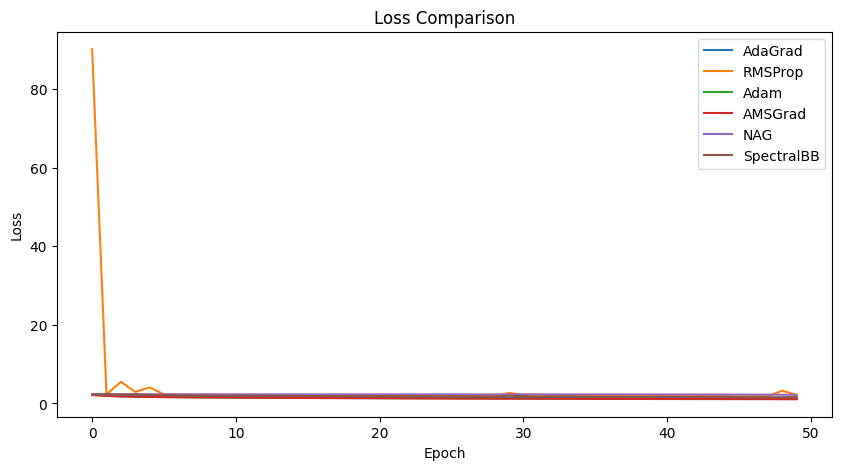

In [101]:
plt.figure(figsize=(10, 5))

for name in results:
    plt.plot(
        results[name]["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.savefig('lesnet_b2048_loss.png')
plt.show()


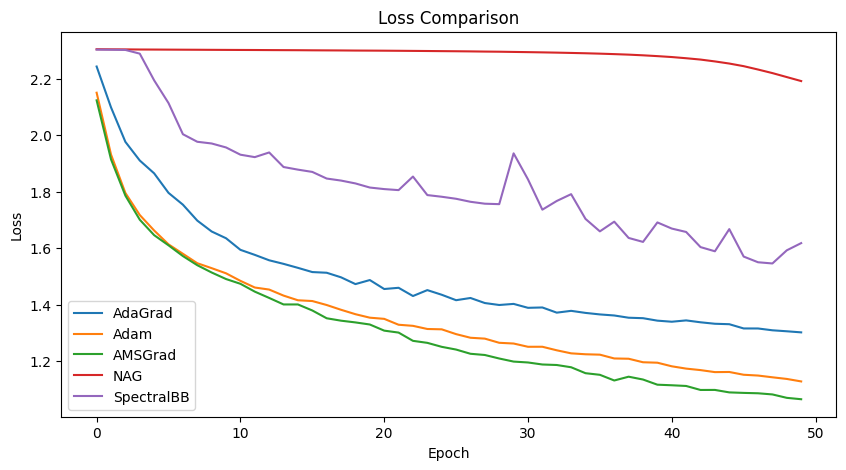

In [102]:
plt.figure(figsize=(10, 5))

for name in nrms:
    plt.plot(
        nrms[name]["loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.savefig('lesnet_loss_without_rmsprop_b2048.png')
plt.show()


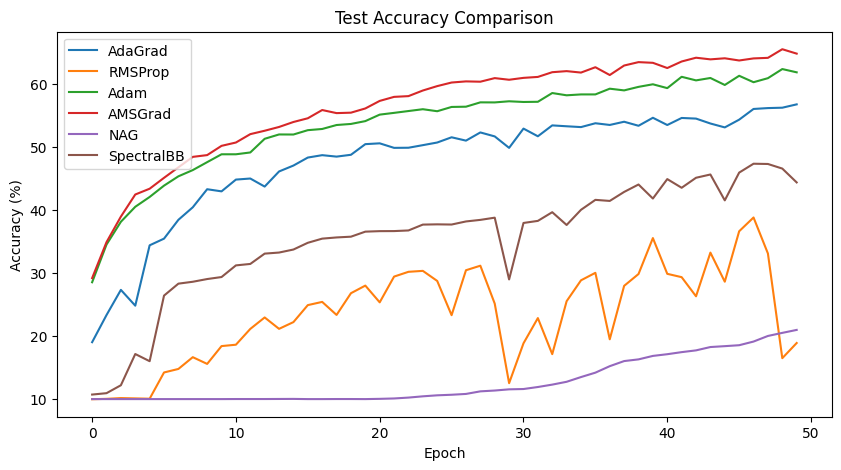

In [103]:
plt.figure(figsize=(10, 5))

for name in results:
    plt.plot(
        results[name]["test_acc"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.savefig('lestnet_b2048_accuracy.png')
plt.show()


In [50]:
summary = []

for name in results:
    summary.append({
        "Optimizer": name,
        "Final Accuracy": results[name]["test_acc"][-1],
        "Final Loss": results[name]["loss"][-1]
    })

pd.DataFrame(summary)

,Optimizer,Final Accuracy,Final Loss
0,AdaGrad,98.31,0.007428
1,RMSProp,93.54,0.562983
2,Adam,98.15,0.023221
3,AMSGrad,98.14,0.024100
4,NAG,97.56,0.058072
5,SpectralBB,98.27,0.005684
